# Pipeline: getting news articles per market

## Keyword generation

In [ ]:
import os
import json
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

client = Groq(api_key=os.getenv("GROQ_API_KEY_1"))

MODEL = "llama-3.3-70b-versatile" # knowledge cutoff in December 2023 (?)

NUM_KEYWORDS = 3
MAX_WORDS = 5

def call_llm(prompt: str) -> str:
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0.2,
    )
    return resp.choices[0].message.content


def extract_queries(text: str):
    for line in text.splitlines():
        if "Search Queries" in line:
            part = line.split(":", 1)[-1]
            queries = [q.strip() for q in part.split(";") if q.strip()]
            return queries
    return []


def build_prompt_1(question, resolution_criteria):
    return f"""I will provide you with a forecasting question and the resolution criteria for the question.
Question: {question}
Resolution criteria: {resolution_criteria}
Task:
- Generate brief search queries (up to {MAX_WORDS} words each) to gather information on Google that could influence the forecast.
You must generate this exact amount of queries: {NUM_KEYWORDS}
Your response should take the following structure: Thoughts: {{ Insert your thinking here. }}
Search Queries: {{ Insert the queries here. Use semicolons to separate the queries. }}"""


def build_prompt_2(question, resolution_criteria):
    return f"""I will provide you with a forecasting question and the resolution criteria for the question. I will
then ask you to generate short search queries (up to {MAX_WORDS} words each) that I’ll use to find
articles on Google News to help answer the question.
Question: {question}
Resolution criteria: {resolution_criteria}
You must generate this exact amount of queries: {NUM_KEYWORDS}
Start off by writing down sub-questions. Then use your sub-questions to help steer the search queries
you produce.
Your response should take the following structure: Thoughts: {{ Insert your thinking here. }}
Search Queries: {{ Insert the queries here. Use semicolons to separate the queries. }}"""


def process_item(item):
    q = item["question"]
    r = item["resolution_criteria"]

    out1 = call_llm(build_prompt_1(q, r))
    out2 = call_llm(build_prompt_2(q, r))

    queries = extract_queries(out1) + extract_queries(out2)

    # deduplicate (case-insensitive)
    seen = set()
    final_queries = []
    for x in queries:
        key = x.lower()
        if key not in seen:
            seen.add(key)
            final_queries.append(x)

    item["search_queries"] = final_queries
    return item

input_path = "data/sample_markets.json"
output_path = "data/sample_markets_queries.json"

os.makedirs("data", exist_ok=True)

with open(input_path, "r", encoding="utf-8") as f:
    data = json.load(f)

enriched = []
for i, item in enumerate(data, start=1):
    print(f"Processing item {i}/{len(data)}: {item.get('question', '')[:60]}...")
    enriched.append(process_item(item))

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(enriched, f, indent=2, ensure_ascii=False)

Processing item 1/10: Will Aljamain Sterling fight Alexander Volkanovski next?...
Processing item 2/10: Will Bilibili Gaming win the LPL 2026 season?...
Processing item 3/10: Will Giorgos Giakoumakis record the most cards in 2025-26 UE...
Processing item 4/10: Will the official USD to ARS exchange rate be between 1700.0...
Processing item 5/10: Abstract FDV above $800M one day after launch?...
Processing item 6/10: Will Amir Albazi be the UFC Flyweight Champion on December 3...
Processing item 7/10: Will Antonio Villaraigosa win the California Governor Electi...
Processing item 8/10: Will Nicolás Maduro be the leader of Venezuela end of 2026?...
Processing item 9/10: Will Seth Jarvis win the 2025–2026 NHL Maurice 'Rocket' Rich...
Processing item 10/10: Predict.fun FDV above $1.5B one day after launch?...


## 1) Get news articles: Google News + GNews

In [35]:
import json
import os
import requests
import time
from dotenv import load_dotenv

load_dotenv(override=True)

API_KEY = os.getenv("GNEWS_API_KEY_2")
INPUT_PATH = "data/sample_markets_queries.json"
OUTPUT_PATH = "data/01_google_news/sample_markets_articles.json"
BASE_URL = "https://gnews.io/api/v4/search"


def to_gnews_format(dt):
    return dt.split(".")[0] + ".000Z"


def clean_query(q):
    q = q.strip()
    # if special characters like "." exist → wrap in quotes
    if any(c in q for c in [".", "-", "!", "?"]):
        return f'"{q}"'
    return q


def fetch_articles(query, start_date, end_date):
    query = clean_query(query)
    print(f"\nQuery: {query}")

    params = {
        "q": query,
        "lang": "en",
        "max": 10,
        "sortby": "publishedAt",
        "from": start_date,
        "to": end_date,
        "apikey": API_KEY
    }

    r = requests.get(BASE_URL, params=params)
    data = r.json()

    if r.status_code != 200:
        print("  API ERROR:", data)
        return []

    articles = data.get("articles", [])
    print(f"  Found {len(articles)} articles")

    results = []

    for i, a in enumerate(articles, start=1):
        print(f"    Article {i}/{len(articles)}")

        results.append({
            "query": query,
            "title": a.get("title"),
            "source": a.get("source", {}).get("name"),
            "published_date": a.get("publishedAt"),
            "url": a.get("url"),
            "full_text": a.get("content")
        })

    return results


with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


enriched = []

print(f"Total markets: {len(data)}")

for mi, market in enumerate(data, start=1):
    print(f"\n\n===== Market {mi}/{len(data)} =====")
    print(market.get("question"))

    start_date = to_gnews_format(market.get("start_date"))
    end_date = to_gnews_format(market.get("today_date"))

    all_articles = []
    seen_urls = set()

    queries = market.get("search_queries", [])
    print(f"Total queries: {len(queries)}")

    for qi, q in enumerate(queries, start=1):
        print(f"\n=== Query {qi}/{len(queries)} ===")

        batch = fetch_articles(q, start_date, end_date)

        for a in batch:
            url = a.get("url")
            if url and url not in seen_urls:
                seen_urls.add(url)
                all_articles.append(a)

        time.sleep(1.05)

    print("\n--- Market Summary ---")
    print(f"Total unique articles: {len(all_articles)}")

    market["articles"] = all_articles
    enriched.append(market)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(enriched, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

Total markets: 10


===== Market 1/10 =====
Will Aljamain Sterling fight Alexander Volkanovski next?
Total queries: 6

=== Query 1/6 ===

Query: Volkanovski next fight
  Found 3 articles
    Article 1/3
    Article 2/3
    Article 3/3

=== Query 2/6 ===

Query: UFC upcoming bouts
  Found 0 articles

=== Query 3/6 ===

Query: Alexander Volkanovski schedule
  Found 0 articles

=== Query 4/6 ===

Query: Alexander Volkanovski next fight
  Found 3 articles
    Article 1/3
    Article 2/3
    Article 3/3

=== Query 5/6 ===

Query: Volkanovski upcoming UFC bout
  Found 0 articles

=== Query 6/6 ===

Query: UFC announces Volkanovski opponent
  Found 0 articles

--- Market Summary ---
Total unique articles: 3


===== Market 2/10 =====
Will Bilibili Gaming win the LPL 2026 season?
Total queries: 6

=== Query 1/6 ===

Query: LPL 2026 schedule
  Found 1 articles
    Article 1/1

=== Query 2/6 ===

Query: Bilibili Gaming roster
  Found 0 articles

=== Query 3/6 ===

Query: LPL season updates
  Foun

In [36]:
import json
import time
import requests
from newspaper import Article
from readability import Document
from bs4 import BeautifulSoup

INPUT_PATH = "data/01_google_news/sample_markets_articles.json"
OUTPUT_PATH = "data/01_google_news/sample_markets_articles_scraped.json"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"
}


def extract_newspaper(url):
    try:
        a = Article(url)
        a.download()
        a.parse()
        if a.text and len(a.text) > 200:
            return a.text
    except Exception:
        pass
    return None


def extract_readability(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)

        if not r.text or len(r.text) < 200:
            print(f"[READABILITY FAIL] Empty HTML: {url}")
            return None

        doc = Document(r.text)
        html = doc.summary()

        if not html or len(html) < 200:
            print(f"[READABILITY FAIL] No content: {url}")
            return None

        soup = BeautifulSoup(html, "html.parser")
        text = soup.get_text("\n")

        return text if len(text) > 200 else None

    except Exception as e:
        print(f"[READABILITY ERROR] {url} -> {type(e).__name__}")
        return None


def extract_fallback(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")
        paragraphs = soup.find_all("p")
        text = "\n".join(p.get_text() for p in paragraphs)
        if len(text) > 200:
            return text
    except Exception:
        pass
    return None


def get_full_text(url):
    text = extract_newspaper(url)
    if text:
        return text

    text = extract_readability(url)
    if text:
        return text

    return extract_fallback(url)


# load file
with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


enriched = []

print(f"Total markets: {len(data)}")

for mi, market in enumerate(data, start=1):
    print(f"\n\n===== Market {mi}/{len(data)} =====")

    articles = market.get("articles", [])
    print(f"Scraping {len(articles)} articles...\n")

    missing = 0

    for i, a in enumerate(articles, start=1):
        url = a.get("url")

        print(f"[{i}/{len(articles)}] {url}")

        if not url:
            continue

        text = get_full_text(url)

        if not text:
            missing += 1

        a["full_text"] = text

        time.sleep(1.0)

    print("\n--- Market Summary ---")
    print(f"Total articles: {len(articles)}")

    if articles:
        print(f"Missing full text: {missing} ({missing/len(articles):.2%})")
    else:
        print(f"Missing full text: {missing} (0%)")

    enriched.append(market)


# save all markets
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(enriched, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

Total markets: 10


===== Market 1/10 =====
Scraping 3 articles...

[1/3] https://www.yardbarker.com/mma/articles/ufc_has_reportedly_decided_between_movsar_evloev_and_jean_silva_for_the_alexander_volkanovski_fight/s1_17651_43670371
[2/3] https://www.yardbarker.com/mma/articles/alexander_volkanovskis_team_strongly_rejects_a_jean_silva_title_shot_barking_like_a_little_dog/s1_17651_43653214
[3/3] https://www.yardbarker.com/mma/articles/movsar_evloevs_title_shot_in_doubt_after_ufc_legend_exposes_dana_whites_lack_of_commitment/s1_17730_43649797

--- Market Summary ---
Total articles: 3
Missing full text: 0 (0.00%)


===== Market 2/10 =====
Scraping 1 articles...

[1/1] https://cricketaddictor.com/cricket-news/lpl-2026-sri-lanka-cricket-reveals-dates-and-four-venues-for-upcoming-season-440467/

--- Market Summary ---
Total articles: 1
Missing full text: 0 (0.00%)


===== Market 3/10 =====
Scraping 0 articles...


--- Market Summary ---
Total articles: 0
Missing full text: 0 (0%)


===== Mark

## 2) Get news articles: NewsAPI.org

In [38]:
import json
import os
import time
import requests
from dotenv import load_dotenv

load_dotenv(override=True)

API_KEY = os.getenv("NEWSAPI_ORG_KEY")

INPUT_PATH = "data/sample_markets_queries.json"
OUTPUT_PATH = "data/02_newsapi_org/sample_markets_articles.json"

BASE_URL = "https://newsapi.org/v2/everything"


def to_newsapi_date(dt):
    return dt.split("T")[0]


def fetch_articles(query, start_date, end_date):
    query = query.strip()
    print(f"\nQuery: {query}")

    params = {
        "q": query,
        "language": "en",
        "pageSize": 10,
        "sortBy": "publishedAt",
        # "from": start_date,
        # "to": end_date,
        "apiKey": API_KEY,
    }

    r = requests.get(BASE_URL, params=params)
    data = r.json()

    if r.status_code != 200:
        print("  API ERROR:", data)
        return []

    articles = data.get("articles", [])
    print(f"  Found {len(articles)} articles")

    results = []

    for i, a in enumerate(articles, start=1):
        print(f"    Article {i}/{len(articles)}")

        results.append({
            "query": query,
            "title": a.get("title"),
            "source": a.get("source", {}).get("name"),
            "published_date": a.get("publishedAt"),
            "url": a.get("url"),
            "full_text": a.get("content")
        })

    return results


with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


enriched = []

print(f"Total markets: {len(data)}")

for mi, market in enumerate(data, start=1):
    print(f"\n\n===== Market {mi}/{len(data)} =====")
    print(market.get("question"))

    start_date = to_newsapi_date(market.get("start_date"))
    end_date = to_newsapi_date(market.get("today_date"))

    queries = market.get("search_queries", [])

    all_articles = []
    seen_urls = set()

    print(f"Total queries: {len(queries)}")

    for qi, q in enumerate(queries, start=1):
        print(f"\n=== Query {qi}/{len(queries)} ===")

        batch = fetch_articles(q, start_date, end_date)

        for a in batch:
            url = a.get("url")
            if url and url not in seen_urls:
                seen_urls.add(url)
                all_articles.append(a)

        time.sleep(1)  # respect rate limits

    print("\n--- Market Summary ---")
    print(f"Total unique articles: {len(all_articles)}")

    market["articles"] = all_articles
    enriched.append(market)


with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(enriched, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

Total markets: 10


===== Market 1/10 =====
Will Aljamain Sterling fight Alexander Volkanovski next?
Total queries: 6

=== Query 1/6 ===

Query: Volkanovski next fight
  Found 10 articles
    Article 1/10
    Article 2/10
    Article 3/10
    Article 4/10
    Article 5/10
    Article 6/10
    Article 7/10
    Article 8/10
    Article 9/10
    Article 10/10

=== Query 2/6 ===

Query: UFC upcoming bouts
  Found 10 articles
    Article 1/10
    Article 2/10
    Article 3/10
    Article 4/10
    Article 5/10
    Article 6/10
    Article 7/10
    Article 8/10
    Article 9/10
    Article 10/10

=== Query 3/6 ===

Query: Alexander Volkanovski schedule
  Found 1 articles
    Article 1/1

=== Query 4/6 ===

Query: Alexander Volkanovski next fight
  Found 10 articles
    Article 1/10
    Article 2/10
    Article 3/10
    Article 4/10
    Article 5/10
    Article 6/10
    Article 7/10
    Article 8/10
    Article 9/10
    Article 10/10

=== Query 5/6 ===

Query: Volkanovski upcoming UFC bout
  F

In [39]:
import json
import time
import requests
from newspaper import Article
from readability import Document
from bs4 import BeautifulSoup

INPUT_PATH = "data/02_newsapi_org/sample_markets_articles.json"
OUTPUT_PATH = "data/02_newsapi_org/sample_markets_articles_scraped.json"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"
}


def extract_newspaper(url):
    try:
        a = Article(url)
        a.download()
        a.parse()
        if a.text and len(a.text) > 200:
            return a.text
    except Exception:
        pass
    return None


def extract_readability(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)

        if not r.text or len(r.text) < 200:
            print(f"[READABILITY FAIL] Empty/short HTML: {url}")
            return None

        doc = Document(r.text)
        html = doc.summary()

        if not html or len(html) < 200:
            print(f"[READABILITY FAIL] No extractable content: {url}")
            return None

        soup = BeautifulSoup(html, "html.parser")
        text = soup.get_text("\n")

        if not text or len(text) < 200:
            print(f"[READABILITY FAIL] Text too short after parsing: {url}")
            return None

        return text

    except Exception as e:
        print(f"[READABILITY ERROR] {url} -> {type(e).__name__}: {e}")
        return None


def extract_fallback(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")
        paragraphs = soup.find_all("p")
        text = "\n".join(p.get_text() for p in paragraphs)
        if len(text) > 200:
            return text
    except Exception:
        pass
    return None


def get_full_text(url):
    text = extract_newspaper(url)
    if text:
        return text

    text = extract_readability(url)
    if text:
        return text

    return extract_fallback(url)


# load file
with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


enriched = []

print(f"Total markets: {len(data)}")

for mi, market in enumerate(data, start=1):
    print(f"\n\n===== Market {mi}/{len(data)} =====")

    articles = market.get("articles", [])
    print(f"Scraping {len(articles)} articles...\n")

    missing = 0

    for i, a in enumerate(articles, start=1):
        url = a.get("url")

        print(f"[{i}/{len(articles)}] {url}")

        if not url:
            continue

        text = get_full_text(url)

        if not text:
            missing += 1

        a["full_text"] = text

        time.sleep(1.0)

    print("\n--- Market Summary ---")
    print(f"Total articles: {len(articles)}")

    if articles:
        print(f"Missing full text: {missing} ({missing/len(articles):.2%})")
    else:
        print(f"Missing full text: {missing} (0%)")

    enriched.append(market)


# save all markets
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(enriched, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

Total markets: 10


===== Market 1/10 =====
Scraping 20 articles...

[1/20] https://www.mmamania.com/ufc-mma-rankings/438491/ufc-dumps-colby-covington-official-welterweight-rankings-debuts-mike-malott-mma
[2/20] https://www.mmafighting.com/latest-news/483738/my-job-was-on-the-line-aaron-pico-treated-ufc-327-fight-like-it-was-a-must-win-after-brutal-knockout-loss-in-his-debut
[3/20] https://mmajunkie.usatoday.com/story/sports/ufc/2026/04/21/ufc-aljamain-sterling-reaction-arman-tsarukyan-featherweight-interest/89714128007/
[4/20] https://www.mmamania.com/ufc-news/438323/ilia-topuria-calls-for-islam-makhachev-super-fight-after-ufc-white-house-card-im-gonna-submit-him
[5/20] https://mmajunkie.usatoday.com/story/sports/ufc/2026/04/20/aljamain-sterling-plans-title-shot-case-ufc-vegas-116/89707912007/
[6/20] https://comicbookmovie.com/video-games/street-fighter/street-fighter-featurette-spotlights-exciting-new-behind-the-scenes-footage-of-the-world-warriors-in-action-a227412
[7/20] https://ww

## 3) Get news articles: NewsCatcher (CatchAll)

In [54]:
import json
import time
from dotenv import load_dotenv
from newscatcher_catchall import CatchAllApi

load_dotenv(override=True)

API_KEY = os.getenv("NEWSCATCHER_API_KEY")
INPUT_PATH = "data/sample_markets_queries.json"
OUTPUT_PATH = "data/03_news_catcher/sample_markets_articles.json"

client = CatchAllApi(api_key=API_KEY)


def run_job(query, start_date, end_date):
    print(f"\nQuery: {query}")

    job = client.jobs.create_job(
        query=query,
        limit=10,
        context=f"Only include articles published between {start_date} and {end_date}"
    )

    job_id = job.job_id

    while True:
        status = client.jobs.get_job_status(job_id)

        if status.status == "completed":
            break

        print("  waiting for job...")
        time.sleep(60)

    results = client.jobs.get_job_results(job_id)

    print(f"  found {results.valid_records} records")

    output = []

    for r in results.all_records:
        output.append({
            "query": query,
            "title": r.record_title,
            "source": getattr(r, "source_name", None),
            "published_date": getattr(r, "published_date", None),
            "url": getattr(r, "url", None),
            "full_text": getattr(r, "content", None)
        })

    return output


# -------------------
# LOAD DATA
# -------------------
with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

all_results = []

for mi, market in enumerate(data, start=1):
    print(f"\n=== MARKET {mi}/{len(data)} ===")

    for qi, q in enumerate(market.get("search_queries", []), start=1):
        print(f"\nQuery {qi}")

        try:
            batch = run_job(
                q,
                market["start_date"],
                market["today_date"]
            )

            all_results.extend(batch)

        except Exception as e:
            print("ERROR:", e)

        time.sleep(2)  # avoid hitting job rate limits


# -------------------
# SAVE
# -------------------
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump([{"articles": all_results}], f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)
print("Total articles:", len(all_results))


=== MARKET 1/10 ===

Query 1

Query: Volkanovski next fight


04/24/2026 12:13:12 PM - HTTP Request: POST https://catchall.newscatcherapi.com/catchAll/submit "HTTP/1.1 200 OK"
04/24/2026 12:13:13 PM - HTTP Request: GET https://catchall.newscatcherapi.com/catchAll/status/446b4b18-87ad-4061-9b4c-838356617978 "HTTP/1.1 200 OK"


  waiting for job...


04/24/2026 12:14:14 PM - HTTP Request: GET https://catchall.newscatcherapi.com/catchAll/status/446b4b18-87ad-4061-9b4c-838356617978 "HTTP/1.1 200 OK"


  waiting for job...


...

ERROR: headers: {'date': 'Fri, 24 Apr 2026 12:03:38 GMT', 'content-type': 'application/json', 'transfer-encoding': 'chunked', 'connection': 'keep-alive', 'server': 'cloudflare', 'x-request-id': 'fcdb6ed8-8daa-4c79-93c3-5379bd85d9e3', 'cf-cache-status': 'DYNAMIC', 'content-encoding': 'gzip', 'cf-ray': '9f14f7454d0fdbab-FRA'}, status_code: 403, body: detail="Your plan does not allow this operation (Jobs_Concurrency: {'usage': 1.0, 'limit': 1})"

Query 3

Query: Predict.fun market sentiment


04/24/2026 02:03:41 PM - HTTP Request: POST https://catchall.newscatcherapi.com/catchAll/submit "HTTP/1.1 403 Forbidden"


ERROR: headers: {'date': 'Fri, 24 Apr 2026 12:03:41 GMT', 'content-type': 'application/json', 'transfer-encoding': 'chunked', 'connection': 'keep-alive', 'server': 'cloudflare', 'x-request-id': 'cbc59565-2d45-41b2-80a8-bcb53d5d18b4', 'cf-cache-status': 'DYNAMIC', 'content-encoding': 'gzip', 'cf-ray': '9f14f753a97adbab-FRA'}, status_code: 403, body: detail="Your plan does not allow this operation (Jobs_Concurrency: {'usage': 1.0, 'limit': 1})"

Query 4

Query: Predict.fun token price


04/24/2026 02:03:43 PM - HTTP Request: POST https://catchall.newscatcherapi.com/catchAll/submit "HTTP/1.1 403 Forbidden"


ERROR: headers: {'date': 'Fri, 24 Apr 2026 12:03:43 GMT', 'content-type': 'application/json', 'transfer-encoding': 'chunked', 'connection': 'keep-alive', 'server': 'cloudflare', 'x-request-id': '2fa5ed0d-4b98-4494-b827-d5074dbaecbd', 'cf-cache-status': 'DYNAMIC', 'content-encoding': 'gzip', 'cf-ray': '9f14f7624d5fdbab-FRA'}, status_code: 403, body: detail="Your plan does not allow this operation (Jobs_Concurrency: {'usage': 1.0, 'limit': 1})"

Saved: data/03_news_catcher/sample_markets_articles.json
Total articles: 200


In [56]:
import json
import os
import re
from collections import defaultdict

INPUT_MARKETS = "data/sample_markets_queries.json"
RESULTS_DIR = "data/03_news_catcher/results"
OUTPUT_PATH = "data/03_news_catcher/sample_markets_articles.json"


def extract_query_from_filename(filename):
    """
    Example:
    results_abstract_token_launch_c60c6cf1-...json
    -> abstract token launch
    """
    name = filename.replace("results_", "").rsplit(".json", 1)[0]

    # remove trailing uuid/timestamp
    name = re.sub(r"_[0-9a-f\-]{8,}.*$", "", name)

    # convert underscores to spaces
    return name.replace("_", " ").strip()

with open(INPUT_MARKETS, "r", encoding="utf-8") as f:
    markets = json.load(f)

query_to_articles = defaultdict(list)

files = [f for f in os.listdir(RESULTS_DIR) if f.endswith(".json")]

print(f"Found {len(files)} result files\n")

for i, filename in enumerate(files, start=1):
    path = os.path.join(RESULTS_DIR, filename)

    query = extract_query_from_filename(filename)
    print(f"[{i}/{len(files)}] {query}")

    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print("  ERROR reading file:", e)
        continue

    for record in data:
        citations = record.get("citations", [])

        for c in citations:
            article = {
                "query": query,
                "title": c.get("title"),
                "source": None,              # not available
                "published_date": c.get("published_date"),
                "url": c.get("link"),
                "full_text": None            # not available
            }

            query_to_articles[query].append(article)

for market in markets:
    market_articles = []

    for q in market.get("search_queries", []):
        q_clean = q.strip().lower()

        # match normalized query
        for stored_query, articles in query_to_articles.items():
            if stored_query.lower() == q_clean:
                market_articles.extend(articles)

    market["articles"] = market_articles

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(markets, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

# optional summary
total_articles = sum(len(m.get("articles", [])) for m in markets)
print("Total articles:", total_articles)

Found 31 result files

[1/31] lpl 2026 season schedule
[2/31] abstract token launch
[3/31] usd exchange rates
[4/31] volkanovski next fight
[5/31] lpl season updates
[6/31] giakoumakis europa league stats
[7/31] ufc flyweight rankings
[8/31] bilibili gaming roster
[9/31] uefa europa league stats
[10/31] uefa europa league card leaders
[11/31] ufc upcoming bouts
[12/31] crypto market trends
[13/31] amir albazi next fight
[14/31] lpl 2026 predictions
[15/31] ufc champion schedule
[16/31] bcra usd to ars rate
[17/31] abstract fdv valuation
[18/31] argentina exchange rate forecast
[19/31] giorgos giakoumakis disciplinary record
[20/31] alexander volkanovski schedule
[21/31] giakoumakis disciplinary record
[22/31] alexander volkanovski next fight
[23/31] abstract governance token
[24/31] volkanovski upcoming ufc bout
[25/31] fdv calculation methods
[26/31] ufc announces volkanovski opponent
[27/31] lpl 2026 schedule
[28/31] bilibili gaming roster 2026
[29/31] argentina currency forecast
[30

In [57]:
import json
import time
import requests
from newspaper import Article
from readability import Document
from bs4 import BeautifulSoup
from urllib.parse import urlparse

INPUT_PATH = "data/03_news_catcher/sample_markets_articles.json"
OUTPUT_PATH = "data/03_news_catcher/sample_markets_articles_scraped.json"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"
}


# -------------------
# SOURCE EXTRACTION
# -------------------
def extract_source_from_url(url):
    try:
        domain = urlparse(url).netloc.lower()
        domain = domain.replace("www.", "")
        return domain
    except:
        return None


def extract_source_from_html(html):
    try:
        soup = BeautifulSoup(html, "html.parser")

        # try meta tags first
        meta = soup.find("meta", property="og:site_name")
        if meta and meta.get("content"):
            return meta["content"]

        meta = soup.find("meta", attrs={"name": "application-name"})
        if meta and meta.get("content"):
            return meta["content"]

    except:
        pass

    return None


# -------------------
# TEXT EXTRACTION
# -------------------
def extract_newspaper(url):
    try:
        a = Article(url)
        a.download()
        a.parse()

        if a.text and len(a.text) > 200:
            return a.text, a.source_url
    except:
        pass

    return None, None


def extract_readability(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)

        if not r.text or len(r.text) < 200:
            return None, None

        doc = Document(r.text)
        html = doc.summary()

        if not html or len(html) < 200:
            return None, None

        soup = BeautifulSoup(html, "html.parser")
        text = soup.get_text("\n")

        if len(text) > 200:
            source = extract_source_from_html(r.text)
            return text, source

    except:
        pass

    return None, None


def extract_fallback(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")

        paragraphs = soup.find_all("p")
        text = "\n".join(p.get_text() for p in paragraphs)

        if len(text) > 200:
            source = extract_source_from_html(r.text)
            return text, source

    except:
        pass

    return None, None


def get_full_text_and_source(url):
    # 1. newspaper
    text, source = extract_newspaper(url)
    if text:
        return text, source

    # 2. readability
    text, source = extract_readability(url)
    if text:
        return text, source

    # 3. fallback
    text, source = extract_fallback(url)
    if text:
        return text, source

    return None, None


# -------------------
# LOAD DATA
# -------------------
with open(INPUT_PATH, "r", encoding="utf-8") as f:
    markets = json.load(f)


# -------------------
# SCRAPE
# -------------------
total_articles = sum(len(m.get("articles", [])) for m in markets)
print(f"Total articles to scrape: {total_articles}\n")

count = 0
missing = 0

for mi, market in enumerate(markets, start=1):
    articles = market.get("articles", [])

    print(f"\n=== MARKET {mi}/{len(markets)} ({len(articles)} articles) ===")

    for i, a in enumerate(articles, start=1):
        count += 1
        url = a.get("url")

        print(f"[{count}/{total_articles}] {url}")

        if not url:
            missing += 1
            continue

        text, source = get_full_text_and_source(url)

        if not text:
            missing += 1

        # fallback source if not extracted
        if not source:
            source = extract_source_from_url(url)

        a["full_text"] = text
        a["source"] = source

        time.sleep(0.5)


# -------------------
# SUMMARY
# -------------------
print("\n=== SUMMARY ===")
print(f"Total articles: {total_articles}")

if total_articles:
    print(f"Missing full text: {missing} ({missing/total_articles:.2%})")
else:
    print("Missing full text: 0 (0%)")


# -------------------
# SAVE
# -------------------
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(markets, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

Total articles to scrape: 4165


=== MARKET 1/10 (337 articles) ===
[1/4165] https://asabnews.com/1001609
[2/4165] https://www.almashhad.com/article/773112298002792-News/874281822302456-%D9%88%D8%B3%D8%B7-%D8%A7%D9%86%D9%87%D9%8A%D8%A7%D8%B1-%D8%A7%D9%84%D9%85%D9%81%D8%A7%D9%88%D8%B6%D8%A7%D8%AA-%D8%AA%D8%B1%D8%A7%D9%85%D8%A8-%D9%8A%D8%B4%D8%A7%D9%87%D8%AF-%D9%85%D8%A8%D8%A7%D8%B1%D8%A7%D8%A9-%D9%82%D8%AA%D8%A7%D9%84%D9%8A%D8%A9-%D9%81%D9%8A-%D9%85%D9%8A%D8%A7%D9%85%D9%8A
[3/4165] https://www.sports.ru/boxing/1117147552-xorxe-masvidal-esli-evloevu-ne-dadut-titulnyj-boj-vsya-sistema-ufc-fal.html
[4/4165] https://custommapposter.com/article/joe-rogan-s-ufc-white-house-card-wish-evloev-vs-volkanovski-for-the-featherweight-title/12609
[5/4165] https://www.sportworldnews.org/ufc/news/28172/mma-arman-tsarukyan-targeting-volkanovski-shows-why-ambition-can-disrupt-an-entire-division-overnight
[6/4165] https://www.sports.ru/boxing/1117136170-aleksej-olejnik-ne-dumayu-chto-volkanovski-sejchas-po

04/27/2026 11:45:11 AM - ruthless removal did not work. 


[72/4165] https://www.metroecuador.com.ec/deportes/2026/04/21/el-ecuatoriano-que-debutara-en-la-ufc-este-fin-de-semana
[73/4165] https://www.actumma.com/william-gomis-est-de-retour-pour-lufc-328-decouvrez-son-adversaire/178617
[74/4165] https://ukranews.com/news/1147381-amosov-debyutiruet-v-rejtinge-ufc-ukrainets-vytesnil-iz-top-15-izvestnogo-amerikantsa
[75/4165] https://champion.com.ua/ukr/mma/ukrajinskiy-boyec-vpershe-uviyshov-u-reyting-ufc-1070777
[76/4165] https://glavcom.ua/sport/news/amosov-vpershe-potrapit-v-rejtinh-ufc-zaminivshi-znamenitoho-bijtsja-1115068.html
[77/4165] https://football24.ua/ru/sport/news/ukrainskij-boec-vpervye-v-karere-popal-v-rejting-ufc-938415
[78/4165] https://inkorr.com/ru/aroslav-amosov-uvijsov-do-rejtingu-ufc-vitisniv-kolbi-kovingtona-z-top-15-318833
[79/4165] https://football24.ua/sport/news/ukrayinskyy-boyets-vpershe-u-karyeri-potrapyv-do-reytynhu-ufc-938414
[80/4165] https://inkorr.com/aroslav-amosov-uvijsov-do-rejtingu-ufc-vitisniv-kolbi-kovingto

04/27/2026 11:50:12 AM - ruthless removal did not work. 


[295/4165] https://www.sports.ru/boxing/1117131978-uznali-legendu-evloev-podelilsya-fotografiej-s-solom-kempbellom.html
[296/4165] https://as.com/autor/cristina-parra-martinez
[297/4165] https://www.wrestlinginc.com/2145348/mma-ufc-steve-garcia-alexander-volkanovski
[298/4165] https://www.sportpreferred.com/news/steve-garcia-targets-alexander-volkanovski-after-bold-ufc-featherweight-title-claim/12754
[299/4165] https://custommapposter.com/article/ufc-legend-frankie-edgar-wants-alex-volkanovski-to-retire-now/12026
[300/4165] https://custommapposter.com/article/why-does-diego-lopes-scratch-his-throat-in-the-octagon-ufc-fighter-explained/12965
[301/4165] https://custommapposter.com/article/alex-volkanovski-breaks-down-diego-lopes-low-fight-iq-in-ufc-title-rematch-volk-s-honest-analysis/13086
[302/4165] https://custommapposter.com/article/will-diego-lopes-title-reign-be-devalued-dan-hardy-weighs-in/12899
[303/4165] https://custommapposter.com/article/ufc-325-volkanovski-vs-lopes-2-who-will

...

[4032/4165] https://cagesidepress.com/2026/04/19/jasmine-jasudavicius-ufc-winnipeg-winning
[4033/4165] https://www.espn.com.br/mma/ufc/artigo/_/id/16593166/karine-killer-sofre-no-grappling-e-perde-para-lutadora-da-casa-no-ufc-canada
[4034/4165] https://thebodylockmma.com/ufc/ufc-results/jasudavicius-dominates-ground-game-to-win-unanimous-decision-over-silva
[4035/4165] https://m-dojo.hatenadiary.com/entry/2026/04/12/012635
[4036/4165] https://www.jutarnji.hr/sportske/fightsite/ufc/ufc-objavio-kompletan-fight-card-za-lipanjsku-priredbu-belal-muhammad-trazi-prekid-crnog-niza-15701504
[4037/4165] https://sports.yahoo.com/articles/ufc-327-start-time-full-142900952.html
[4038/4165] https://www.jutarnji.hr/sportske/fightsite/ostalo/borilacki-tjedan-ponajbolji-hrvatski-kikboksac-krece-po-trecu-uzastopnu-pobjedu-unutar-gloryja-15701160
[4039/4165] https://www.world-today-news.com/ufc-327-results-prochazka-vs-ulberg-highlights-and-interviews
[4040/4165] https://www.tribute.ca/movies/ufc-327-pro

04/27/2026 02:01:26 PM - ruthless removal did not work. 


[4054/4165] https://custommapposter.com/article/ufc-327-joshua-van-vs-tatsuro-taira-first-title-defense-preview/12021
[4055/4165] https://custommapposter.com/article/joshua-van-s-historic-flyweight-title-win-at-ufc-323/12124
[4056/4165] https://sports.sohu.com/a/1009507978_121332532
[4057/4165] https://www.163.com/dy/article/KQHF4MMO05568W0A.html
[4058/4165] https://m.163.com/dy/article/KQHF4MMO05568W0A.html
[4059/4165] https://www.sohu.com/a/1009431173_163278
[4060/4165] https://www.uol.com.br/esporte/ultimas-noticias/ag-fight/2026/04/14/alexa-grasso-exalta-trabalho-mental-para-voltar-a-vencer-no-ufc-orgulhosa-de-mim.htm
[4061/4165] https://sportarena.kz/mma-ufc/1053097-khamzat-chimaev-rasskazal-o-svoikh-otnosheniyakh-s-khabibom-nurmagomedovym.html
[4062/4165] https://zamin.uz/ru/sport/196812-hamzat-chimaev-habib-nurmagomedov-haqida-munosabatlarda-muammo-yoq.html
[4063/4165] https://zamin.uz/fr/sport/196812-khamzat-chimaev-sur-khabib-nurmagomedov-aucune-tension-entre-eux.html
[4064/41

04/27/2026 02:04:04 PM - ruthless removal did not work. 


[4139/4165] https://www.wrestlinginc.com/2145072/mma-ufc-327-jiri-prochazka-carlos-ulberg-full-fight-card-preview-matches
[4140/4165] https://www.ouniversodatv.com/2026/04/ufc-327-jiri-prochazka-enfrenta-carlos.html
[4141/4165] https://www.yardbarker.com/mma/articles/3_biggest_takeaways_from_ufc_327/s1_17702_43718340
[4142/4165] https://custommapposter.com/article/why-jiri-prochazka-will-never-break-his-habit-demetrious-johnson-explains-ufc-327/13714
[4143/4165] https://sport.russia24.pro/425681882
[4144/4165] https://www.gazeta.press/sport/news/2026/04/18/28293853.shtml
[4145/4165] https://sports.sohu.com/a/1009507978_121332532
[4146/4165] https://www.sohu.com/a/1009431173_163278
[4147/4165] https://m.163.com/dy/article/KQHF4MMO05568W0A.html
[4148/4165] https://www.163.com/dy/article/KQHF4MMO05568W0A.html
[4149/4165] https://www.telecomasia.net/news/mma/tsarukyan-reveals-tentative-date-for-his-fight-with-ufc-bjj-champion-musumeci
[4150/4165] https://www.blackbeltmag.com/post/demetriou

In [59]:
import json
from urllib.parse import urlparse

INPUT_PATH = "data/03_news_catcher/sample_markets_articles_scraped.json"
OUTPUT_PATH = "data/03_news_catcher/sample_markets_articles_scraped.json"


def clean_source(url):
    if not url:
        return url

    try:
        domain = urlparse(url).netloc.lower()

        if not domain:
            return url  # fallback if parsing fails

        domain = domain.replace("www.", "")

        # split but keep unicode safely
        parts = domain.split(".")
        if len(parts) > 1:
            return parts[0]
        return domain

    except Exception:
        return url


with open(INPUT_PATH, "r", encoding="utf-8") as f:
    markets = json.load(f)


for market in markets:
    for article in market.get("articles", []):
        original = article.get("source")

        # preserve original
        article["source_url"] = original

        # cleaned version
        article["source"] = clean_source(original)


with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(markets, f, indent=2, ensure_ascii=False)

print("Done.")

Done.


## Comparison of news APIs


===== 02_newsapi_org =====
Earliest article: 24 March 2026
Latest article:   23 April 2026

===== 03_news_catcher =====
Earliest article: 10 April 2026
Latest article:   23 April 2026

===== 01_google_news =====
Earliest article: 25 March 2026
Latest article:   22 April 2026


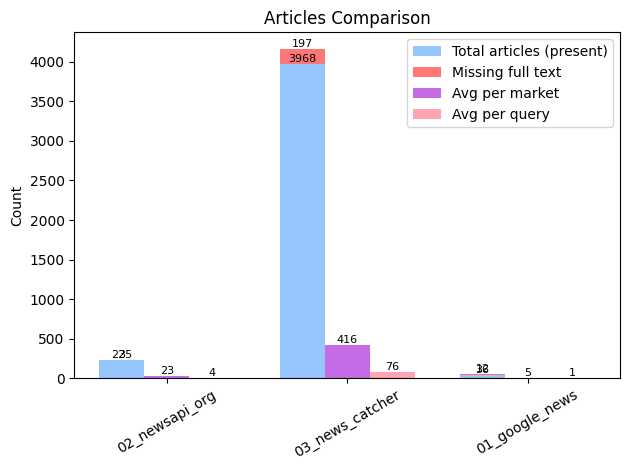

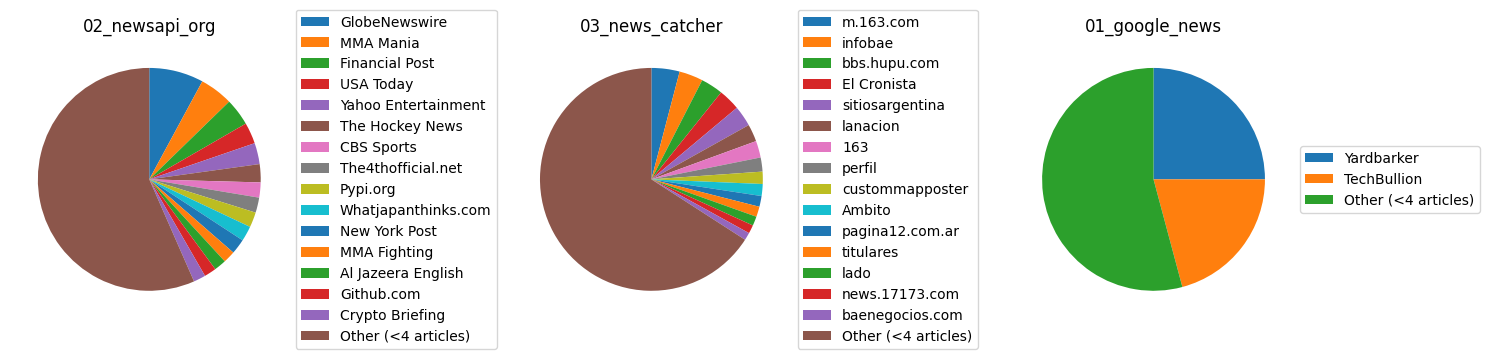

In [61]:
import json
import os
from collections import defaultdict
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = "data"


def load_all_files():
    datasets = {}

    for folder in os.listdir(BASE_DIR):
        if not folder.startswith(tuple([f"{i:02d}_" for i in range(1, 10)])):
            continue

        path = os.path.join(BASE_DIR, folder, "sample_markets_articles_scraped.json")

        if not os.path.exists(path):
            continue

        with open(path, "r", encoding="utf-8") as f:
            datasets[folder] = json.load(f)

    return datasets


def parse_date(d):
    if not d:
        return None
    try:
        return datetime.fromisoformat(d.replace("Z", "+00:00"))
    except Exception:
        return None


def fmt_date(d):
    return d.strftime("%d %B %Y") if d else "N/A"


datasets = load_all_files()

metrics = {}

for name, markets in datasets.items():
    total_articles = 0
    total_queries = 0
    total_markets = len(markets)

    source_counts = defaultdict(int)
    missing_full = 0
    all_dates = []

    for market in markets:
        articles = market.get("articles", [])
        queries = market.get("search_queries", [])

        total_articles += len(articles)
        total_queries += len(queries)

        for a in articles:
            if not a.get("full_text"):
                missing_full += 1

            src = a.get("source") or "Unknown"
            source_counts[src] += 1

            d = parse_date(a.get("published_date"))
            if d:
                all_dates.append(d)

    metrics[name] = {
        "total": total_articles,
        "missing": missing_full,
        "avg_market": total_articles / total_markets if total_markets else 0,
        "avg_query": total_articles / total_queries if total_queries else 0,
        "sources": source_counts,
        "earliest": min(all_dates) if all_dates else None,
        "latest": max(all_dates) if all_dates else None
    }

for name, m in metrics.items():
    print(f"\n===== {name} =====")
    print(f"Earliest article: {fmt_date(m['earliest'])}")
    print(f"Latest article:   {fmt_date(m['latest'])}")

# =========================
# GROUPED BAR PLOT
# =========================

labels = list(metrics.keys())
x = np.arange(len(labels))
width = 0.25

totals = np.array([metrics[k]["total"] for k in labels])
missing = np.array([metrics[k]["missing"] for k in labels])
present = totals - missing
avg_market = np.array([metrics[k]["avg_market"] for k in labels])
avg_query = np.array([metrics[k]["avg_query"] for k in labels])

plt.figure()

# bars
b1 = plt.bar(x - width, present, width, color="#97C6FF", label="Total articles (present)")
b2 = plt.bar(x - width, missing, width, bottom=present, color="#FF7676", label="Missing full text")

b3 = plt.bar(x, avg_market, width, color="#C56BE5", label="Avg per market")
b4 = plt.bar(x + width, avg_query, width, color="#FFA4B3", label="Avg per query")

# add labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height,
                f"{height:.0f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

add_labels(b1)
add_labels(b2)
add_labels(b3)
add_labels(b4)

plt.xticks(x, labels, rotation=30)
plt.title("Articles Comparison")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# PIE CHARTS
# =========================

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))

if len(metrics) == 1:
    axes = [axes]

for ax, (name, m) in zip(axes, metrics.items()):
    sources = dict(m["sources"])

    # sort all sources descending
    sorted_sources = sorted(sources.items(), key=lambda x: x[1], reverse=True)

    # keep only >3 articles
    filtered = [(k, v) for k, v in sorted_sources if v > 3]

    # take top 15
    top = filtered[:15]

    # everything else → other
    other = sum(v for k, v in sorted_sources if (k, v) not in top)

    labels = [k for k, _ in top]
    values = [v for _, v in top]

    if other > 0:
        labels.append("Other (<4 articles)")
        values.append(other)

    wedges, _ = ax.pie(values, startangle=90, counterclock=False)

    ax.set_title(name)

    ax.legend(
        wedges,
        labels,
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

plt.tight_layout()
plt.show()